In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/user_daily_features.csv")
print(df.shape)
df.head()

(330268, 17)


,user,day,logon_count,after_hours_logon_count,distinct_pc_count,usb_connect_count,file_access_count,email_count,email_external_count,is_insider_day,logon_count_zscore,after_hours_logon_count_zscore,distinct_pc_count_zscore,usb_connect_count_zscore,file_access_count_zscore,email_count_zscore,email_external_count_zscore
0,AAE0190,2010-01-04,1,0,1,0.0,0.0,14.0,2.0,0,0.0,0.0,0.0,0.0,0.0,0.284033,-1.338417
1,AAE0190,2010-01-05,1,0,1,0.0,0.0,13.0,7.0,0,0.0,0.0,0.0,0.0,0.0,-0.454880,0.160264
2,AAE0190,2010-01-06,1,0,1,0.0,0.0,14.0,6.0,0,0.0,0.0,0.0,0.0,0.0,0.284033,-0.139473
3,AAE0190,2010-01-07,1,0,1,0.0,0.0,14.0,5.0,0,0.0,0.0,0.0,0.0,0.0,0.284033,-0.439209
4,AAE0190,2010-01-08,1,0,1,0.0,0.0,13.0,3.0,0,0.0,0.0,0.0,0.0,0.0,-0.454880,-1.038681


In [8]:
insider_counts = df['is_insider_day'].value_counts()
print(insider_counts)
print(f"\nInsider day percentage: {df['is_insider_day'].mean() * 100:.3f}%")

is_insider_day
0    328906
1      1362
Name: count, dtype: int64

Insider day percentage: 0.412%


In [9]:
comparison = df.groupby('is_insider_day')[
    ['logon_count', 'after_hours_logon_count', 'distinct_pc_count', 'usb_connect_count']
].mean()
comparison.index = ['Normal Days', 'Insider Days']
comparison

,logon_count,after_hours_logon_count,distinct_pc_count,usb_connect_count
Normal Days,1.424814,0.095666,1.151825,0.607198
Insider Days,1.439794,0.187959,1.199706,2.654185


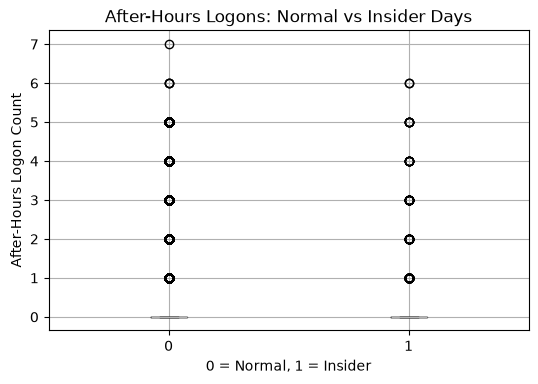

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='after_hours_logon_count', by='is_insider_day', ax=ax)
plt.title('After-Hours Logons: Normal vs Insider Days')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Insider')
plt.ylabel('After-Hours Logon Count')
plt.savefig('../outputs/plots/after_hours_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

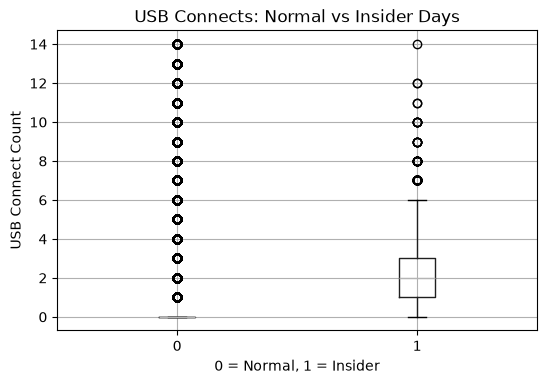

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='usb_connect_count', by='is_insider_day', ax=ax)
plt.title('USB Connects: Normal vs Insider Days')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Insider')
plt.ylabel('USB Connect Count')
plt.savefig('../outputs/plots/usb_connects_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

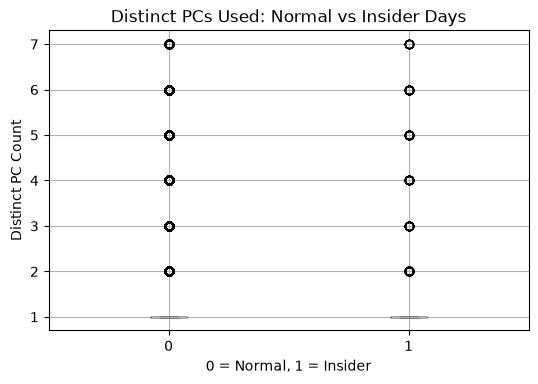

In [12]:
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='distinct_pc_count', by='is_insider_day', ax=ax)
plt.title('Distinct PCs Used: Normal vs Insider Days')
plt.suptitle('')
plt.xlabel('0 = Normal, 1 = Insider')
plt.ylabel('Distinct PC Count')
plt.savefig('../outputs/plots/distinct_pc_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

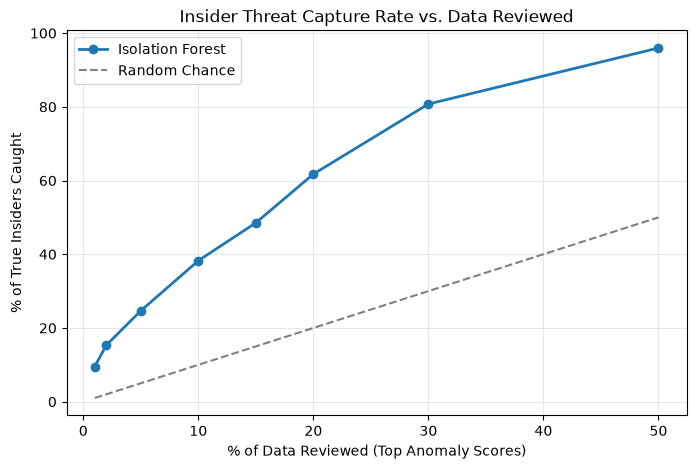

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("../data/processed/user_daily_features_with_flags.csv")

total_insiders = results_df['is_insider_day'].sum()
df_sorted = results_df.sort_values('iso_forest_score', ascending=False)

percentages = [0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
capture_rates = []

for pct in percentages:
    top_n = int(len(df_sorted) * pct)
    caught = df_sorted.head(top_n)['is_insider_day'].sum()
    capture_rates.append(caught / total_insiders * 100)

plt.figure(figsize=(8,5))
plt.plot([p*100 for p in percentages], capture_rates, marker='o', linewidth=2, label='Isolation Forest')
plt.plot([p*100 for p in percentages], [p*100 for p in percentages], linestyle='--', color='gray', label='Random Chance')
plt.xlabel('% of Data Reviewed (Top Anomaly Scores)')
plt.ylabel('% of True Insiders Caught')
plt.title('Insider Threat Capture Rate vs. Data Reviewed')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../outputs/plots/capture_rate_chart.png', dpi=150, bbox_inches='tight')
plt.show()